In [17]:
from __future__ import annotations

from os import PathLike
from typing import Any, Literal, Sequence
from types import EllipsisType

import numpy as np
from numpy.typing import DTypeLike

from pyflim.PTU.reader import PTUFile, PTUArray5D
from phasorpy.phasor import phasor_from_signal

In [18]:
from pyflim.PTU.tools import signal_from_PTUFile

In [19]:
# Load with spatial binning to boost photon counts per pixel
signal = signal_from_PTUFile('TTTT.ptu', dtype=np.uint32, binning=4)

In [20]:
# H (histogram) is the last axis — tell phasor_from_signal to use it
mean, real, imag = phasor_from_signal(signal, axis='H')

In [21]:
from pyflim.phasor.signal import calibrate_signal_with_irf, get_phasor_irf

# ── Read IRF from the spreadsheet ──
xlsx ='TTTT.xlsx'
irf_time_ns, irf_counts = get_phasor_irf(xlsx)
real_cal, imag_cal = calibrate_signal_with_irf(signal, real, imag, irf_time_ns, irf_counts, signal.frequency)


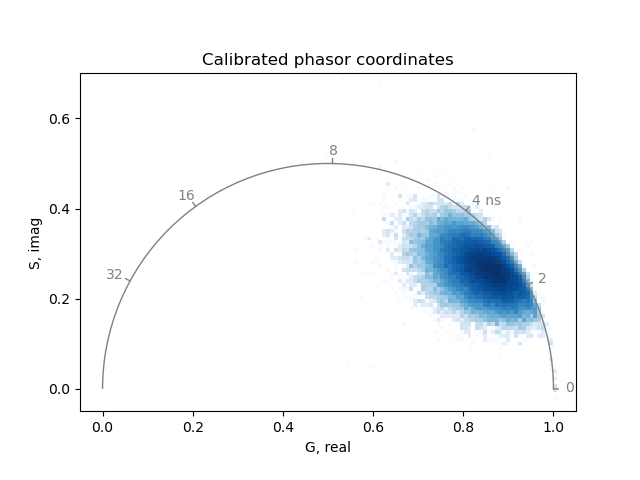

In [22]:
from phasorpy.plot import plot_phasor

frequency = signal.attrs['frequency']

plot_phasor(
    real_cal,
    imag_cal,
    frequency=frequency,
    title='Calibrated phasor coordinates',
)

Plotting 65031 valid pixels


Output()

ℹ  Click on the phasor to place elliptical cursors. First two define the decomposition line.


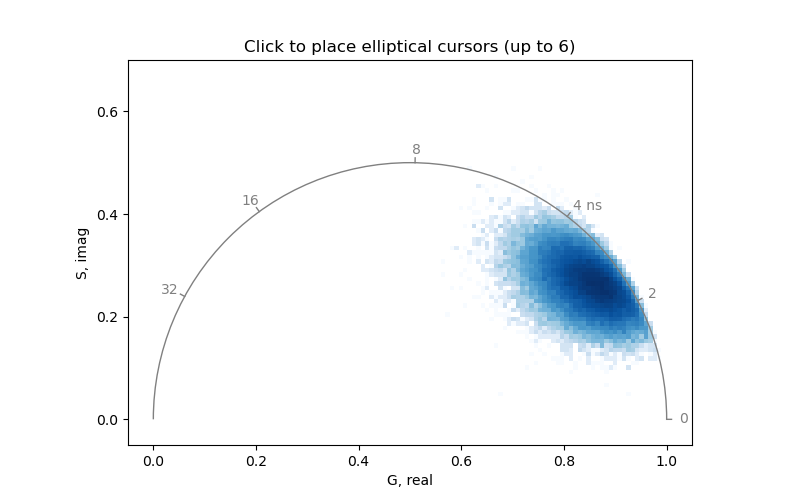

In [ ]:
%matplotlib widget
import matplotlib
matplotlib.use('module://ipympl.backend_nbagg')

from pyflim.phasor.interactive import phasor_cursor_tool

state = phasor_cursor_tool(real_cal, imag_cal, mean, frequency)

Found 1 peak(s) in the phasor histogram

Peak        G        S   τ_φ (ns)   τ_m (ns)   phase(°)     mod
--------------------------------------------------------------------
   1   0.8613   0.2675      2.534      3.908      17.25  0.9019

Peak 1: INSIDE semicircle (dist=0.050) → multi-exponential mixture
          Apparent τ_φ = 2.53 ns,  τ_m = 3.91 ns
          Two-component bracket:  τ_short < 2.53 ns  <  τ_long > 3.91 ns


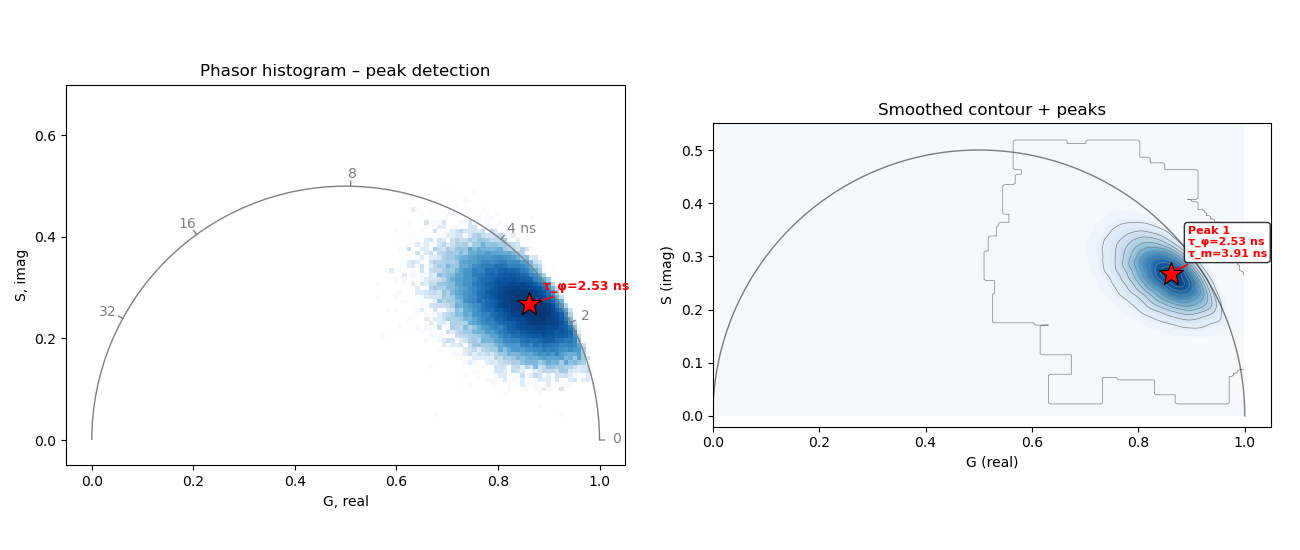

In [24]:
"""
Peak-finding on the 2-D phasor histogram → automatic τ estimation.
"""
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label, maximum_filter, center_of_mass
from phasorpy.phasor import phasor_to_polar
from phasorpy.lifetime import phasor_to_apparent_lifetime, phasor_from_lifetime
from phasorpy.plot import PhasorPlot

# ── 1. Build 2-D histogram of calibrated phasor coords ──
rc_ = real_cal.squeeze().astype(float)
ic_ = imag_cal.squeeze().astype(float)
mn_ = mean.squeeze().astype(float)
mask = (mn_ >= 0.01) & ~np.isnan(rc_)

g_vals = rc_[mask]
s_vals = ic_[mask]

n_bins_hist = 256
hist, g_edges, s_edges = np.histogram2d(
    g_vals, s_vals, bins=n_bins_hist,
    range=[[0, 1], [0, 0.55]])
g_centers = 0.5 * (g_edges[:-1] + g_edges[1:])
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

# ── 2. Smooth & find peaks ──
sigma = 3.0                            # Gaussian smoothing σ (bins)
hist_smooth = gaussian_filter(hist, sigma=sigma)

# Local-maximum detection: a pixel is a peak if it equals the
# neighbourhood maximum and exceeds a fraction of the global max
neighbourhood = 15                     # footprint radius (bins)
local_max = maximum_filter(hist_smooth, size=neighbourhood)
threshold = 0.10 * hist_smooth.max()   # 10% of global peak
peak_mask = (hist_smooth == local_max) & (hist_smooth > threshold)

labelled, n_peaks = label(peak_mask)
print(f"Found {n_peaks} peak(s) in the phasor histogram\n")

# ── 3. Get peak centres (weighted centroids) ──
peak_coords = center_of_mass(hist_smooth, labelled, range(1, n_peaks + 1))

peak_g = []
peak_s = []
for (ig, is_) in peak_coords:
    peak_g.append(np.interp(ig, np.arange(n_bins_hist), g_centers))
    peak_s.append(np.interp(is_, np.arange(n_bins_hist), s_centers))

peak_g = np.array(peak_g)
peak_s = np.array(peak_s)

# ── 4. Convert to apparent lifetime ──
tau_phase, tau_mod = phasor_to_apparent_lifetime(peak_g, peak_s, frequency)
phase_vals, mod_vals = phasor_to_polar(peak_g, peak_s)

print(f"{'Peak':>4}  {'G':>7}  {'S':>7}  {'τ_φ (ns)':>9}  {'τ_m (ns)':>9}  {'phase(°)':>9}  {'mod':>6}")
print("-" * 68)
for i in range(n_peaks):
    print(f"{i+1:4d}  {peak_g[i]:7.4f}  {peak_s[i]:7.4f}  "
          f"{tau_phase[i]:9.3f}  {tau_mod[i]:9.3f}  "
          f"{np.degrees(phase_vals[i]):9.2f}  {mod_vals[i]:6.4f}")

# ── 5. Assess: single vs multi-component ──
# If the peak sits ON the semicircle → single-exponential
# If inside → mixture of lifetimes
print()
for i in range(n_peaks):
    r = np.sqrt((peak_g[i] - 0.5)**2 + peak_s[i]**2)
    on_circle = abs(r - 0.5)
    if on_circle < 0.02:
        print(f"Peak {i+1}: ON the universal semicircle → single-exponential,  τ ≈ {tau_phase[i]:.2f} ns")
    else:
        print(f"Peak {i+1}: INSIDE semicircle (dist={on_circle:.3f}) → multi-exponential mixture")
        print(f"          Apparent τ_φ = {tau_phase[i]:.2f} ns,  τ_m = {tau_mod[i]:.2f} ns")
        if tau_phase[i] > 0 and tau_mod[i] > 0:
            # For a two-component mixture, τ_φ < τ_m always
            # A rough bracket: the shorter lifetime < τ_φ, the longer > τ_m
            print(f"          Two-component bracket:  τ_short < {tau_phase[i]:.2f} ns  <  τ_long > {tau_mod[i]:.2f} ns")

# ── 6. Plot: smoothed histogram with peaks marked ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: 2D histogram with peak markers
ax = axes[0]
pp = PhasorPlot(frequency=frequency, ax=ax, title='Phasor histogram – peak detection')
pp.hist2d(g_vals, s_vals)
for i in range(n_peaks):
    ax.plot(peak_g[i], peak_s[i], 'r*', ms=18, markeredgecolor='k',
            markeredgewidth=0.8, zorder=20)
    ax.annotate(f'τ_φ={tau_phase[i]:.2f} ns',
                xy=(peak_g[i], peak_s[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# Right: smoothed histogram as contour + peaks
ax2 = axes[1]
GG, SS = np.meshgrid(g_centers, s_centers)
ax2.contourf(GG, SS, hist_smooth.T, levels=30, cmap='Blues')
ax2.contour(GG, SS, hist_smooth.T, levels=10, colors='grey', linewidths=0.5)
for i in range(n_peaks):
    ax2.plot(peak_g[i], peak_s[i], 'r*', ms=18, markeredgecolor='k',
             markeredgewidth=0.8, zorder=20)
    ax2.annotate(f'Peak {i+1}\nτ_φ={tau_phase[i]:.2f} ns\nτ_m={tau_mod[i]:.2f} ns',
                 xy=(peak_g[i], peak_s[i]),
                 xytext=(12, 12), textcoords='offset points',
                 fontsize=8, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
# Draw semicircle
theta = np.linspace(0, np.pi, 200)
ax2.plot(0.5 + 0.5*np.cos(theta), 0.5*np.sin(theta), 'k-', lw=1, alpha=0.5)
ax2.set_xlabel('G (real)')
ax2.set_ylabel('S (imag)')
ax2.set_title('Smoothed contour + peaks')
ax2.set_xlim(0, 1.05)
ax2.set_ylim(-0.02, 0.55)
ax2.set_aspect('equal')

fig.tight_layout()
plt.show()